# Space Invaders - Reinforcement Learning Projekat

## 1. Opis problema

Space Invaders je arkadna igra u kojoj igrač kontroliše top na dnu ekrana i puca na vanzemaljce koji se spuštaju odozgo. Cilj je uništiti sve vanzemaljce pre nego što stignu do dna.

### Zašto je ovo RL problem?

Agent (top) mora da nauči **strategiju** igranja bez eksplicitnog programiranja pravila. Umesto da ručno kodiramo "pucaj kad je neprijatelj iznad tebe", agent **sam otkriva** optimalnu strategiju kroz pokušaje i greške (trial and error).

### MDP Formulacija (Markov Decision Process)

Svaki RL problem se definiše kao MDP sa 4 komponente:

- **State (stanje okruženja):** Pozicija agenta na gridu (`agent_col`), lista pozicija svih neprijatelja (`enemies` - svaki sa redom i kolonom), pozicija metka (`bullet` - red i kolona, ili None), smer kretanja neprijatelja (`enemy_direction`), brojač koraka (`step_count`)
- **Action (akcija):** Levo, desno, pucaj, stoj (4 akcije)
- **Reward (nagrada):** Pogodak (+10), promašaj (-1), preživljavanje (+1), poraz (-100), pobeda (+50)
- **Transition (prelaz):** Deterministički - akcija uvek daje isti rezultat

### Poređenje algoritama

Poredićemo dva algoritma:
- **Q-Learning** (off-policy) - uči iz najboljeg mogućeg poteza, optimistično
- **SARSA** (on-policy) - uči iz poteza koji je stvarno odigrao, opreznije

### Diskretizacija stanja

Kompletno stanje okruženja (pozicije svih neprijatelja, metka, itd.) ima previše kombinacija za Q-tabelu. Zato ga **diskretizujemo** - svodimo na manji skup informacija koje su najbitnije za donošenje odluke:

1. **Relativna pozicija najbližeg neprijatelja** - razlika kolone neprijatelja i agenta, grupisana u 7 kategorija (daleko levo, levo, blago levo, iznad, blago desno, desno, daleko desno)
2. **Zona opasnosti** - koliko je najbliži neprijatelj blizu dna (4 zone: daleko/srednje/blizu/opasno)
3. **Status metka** - da li je metak u vazduhu, 0 ili 1 (agent može imati samo jedan metak)
4. **Broj preostalih neprijatelja** - grupisano u 3 kategorije (malo/srednje/mnogo)
5. **Pozicija kod zida** - da li je agent uz levi/desni zid ili u sredini (3 kategorije)

Ukupan broj diskretizovanih stanja: 7 × 4 × 2 × 3 × 3 = **504** - idealno za Q-tabelu.

---

## 2. Importi i podešavanja

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random
from collections import defaultdict
from tqdm import tqdm

# Seed za reproduktivnost rezultata
random.seed(42)
np.random.seed(42)

## 3. Game Engine - Space Invaders Environment

Ovo je **srce projekta** - klasa koja simulira igru Space Invaders.

Grid je veličine 10 kolona × 8 redova:
- Agent (top) je na dnu (red 7) i može da se kreće levo/desno
- Neprijatelji su u gornjim redovima i polako se spuštaju
- Agent može da ispali metak koji leti nagore (2 reda po koraku - dovoljno brzo da pogodi)

```
Red 0:  . . E . E . . E . .    E = neprijatelj
Red 1:  . . . . . . . . . .    . = prazno
Red 2:  . . . . . . . . . .    A = agent (top)
Red 3:  . . . . . . . . . .    | = metak
Red 4:  . . . . . . . . . .
Red 5:  . . . | . . . . . .    Metak leti nagore (2 reda po koraku)
Red 6:  . . . . . . . . . .
Red 7:  . . . A . . . . . .    Agent je uvek u redu 7
```

### Stanje okruženja (kompletno stanje igre)

Kompletno stanje igre je definisano sledećim varijablama koje se inicijalizuju u `reset()` funkciji:
- `agent_col` - kolona u kojoj se agent nalazi (0-9)
- `agent_row` - red agenta (fiksno 7, donji red)
- `enemies` - lista pozicija svih neprijatelja, svaki je [red, kolona]
- `bullet` - pozicija metka [red, kolona] ili None ako nema metka
- `step_count` - ukupan broj odigranih koraka (koristi se za tajming pomeranja neprijatelja)
- `enemy_direction` - trenutni smer kretanja neprijatelja (1 = desno, -1 = levo)

### Diskretizacija stanja za Q-tabelu

Kompletno stanje (posebno lista `enemies` koja može imati razne kombinacije pozicija) je preveliko za tabelarni pristup. Funkcija `_get_state()` ga diskretizuje u torku od 5 elemenata koja čuva samo ono što je najbitnije za odluku agenta. Detalji diskretizacije su opisani u docstringu te funkcije.

### Ključne dizajn odluke

- **Metak se kreće 2 reda po koraku** - tako može da stigne do vrha za 3 koraka (umesto 6), što daje realnu šansu za pogodak jer se neprijatelji pomeraju svaka 3 koraka
- **Nearest enemy je deterministički** - kad je više neprijatelja u istom redu, biramo onog koji je bliži agentu (ne nasumičnog)
- **Diskretizovano stanje koristi relativne pozicije** - agent uči paterne umesto specifičnih pozicija

In [3]:
class SpaceInvadersEnvironment:
    """
    Space Invaders Environment za Reinforcement Learning.

    Grid: 10 kolona x 8 redova
    Agent: Donji red (red 7), kreće se levo/desno, puca
    Neprijatelji: Spuštaju se odozgo, periodično se pomeraju
    Metak: Leti 2 reda po koraku (brz metak za realnu šansu pogotka)

    Akcije:
        0 = LEVO
        1 = DESNO
        2 = PUCAJ
        3 = STOJ (ne radi ništa)
    """

    def __init__(self, width=10, height=8, num_enemies=6, enemy_move_interval=3):
        self.width = width                             # Širina grida (broj kolona)
        self.height = height                           # Visina grida (broj redova)
        self.num_enemies = num_enemies                 # Početni broj neprijatelja
        self.enemy_move_interval = enemy_move_interval # Na koliko koraka se neprijatelji pomere

        self.action_space = [0, 1, 2, 3]               # LEVO, DESNO, PUCAJ, STOJ
        self.action_names = ['LEVO', 'DESNO', 'PUCAJ', 'STOJ']

        self.reset()

    def reset(self):
        """
        Resetuje igru na početno stanje.
        Postavlja agenta na sredinu dna, kreira neprijatelje na vrhu.
        """
        self.agent_col = self.width // 2
        self.agent_row = self.height - 1  # Uvek u poslednjem redu

        # Kreiramo neprijatelje u gornja 2 reda, na nasumičnim kolonama
        self.enemies = []
        enemy_cols = random.sample(range(self.width), min(self.num_enemies, self.width))
        for i, col in enumerate(enemy_cols):
            row = i % 2  # Raspoređujemo u red 0 i red 1
            self.enemies.append([row, col])

        self.bullet = None          # None = nema metka u vazduhu
        self.step_count = 0         # Brojač koraka za pomeranje neprijatelja
        self.enemy_direction = 1    # Smer kretanja: 1=desno, -1=levo

        # Statistike
        self.total_kills = 0
        self.total_shots = 0

        return self._get_state()

    def _find_nearest_enemy(self):
        """
        Pronalazi najbližeg neprijatelja (najveći red = najbliži dnu).
        Kad je više u istom redu, bira onog koji je bliži agentu po koloni.
        Ovo je deterministički - isti input uvek daje isti output.
        """
        if not self.enemies:
            return None

        max_row = max(e[0] for e in self.enemies)
        candidates = [e for e in self.enemies if e[0] == max_row]

        # Od kandidata u istom redu, biramo najbližeg po koloni
        return min(candidates, key=lambda e: abs(e[1] - self.agent_col))

    def _get_state(self):
        """
        Diskretizuje pravo stanje igre u torku za Q-tabelu.
        Pravo stanje (agent_col, enemies, bullet, itd.) je preveliko,
        pa ga svodimo na manji skup korišćenjem relativnih pozicija.

        Diskretizovano stanje: (relative_col, zone, bullet_active, enemy_count_bucket, wall_position)

        relative_col: Razlika kolone neprijatelja i agenta, u 7 kategorija:
            0 = daleko levo (≤-3)
            1 = levo (-2)
            2 = blago levo (-1)
            3 = iznad (0)
            4 = blago desno (+1)
            5 = desno (+2)
            6 = daleko desno (≥+3)

        zone: Diskretizovan red neprijatelja u 4 zone:
            0 = daleko (red 0-1)
            1 = srednje (red 2-3)
            2 = blizu (red 4-5)
            3 = opasno blizu (red 6-7)

        bullet_active: 0 ili 1

        enemy_count_bucket:
            0 = malo (1-2)
            1 = srednje (3-4)
            2 = mnogo (5+)

        wall_position:
            0 = uz levi zid (kolona 0-1)
            1 = sredina (kolona 2-7)
            2 = uz desni zid (kolona 8-9)
        """
        nearest = self._find_nearest_enemy()

        if nearest is None:
            return (3, 0, 0, 0, 1)  # Nema neprijatelja - neutralno stanje

        # 1. Relativna pozicija (kolona neprijatelja - kolona agenta)
        diff = nearest[1] - self.agent_col
        if diff <= -3:
            rel_col = 0
        elif diff == -2:
            rel_col = 1
        elif diff == -1:
            rel_col = 2
        elif diff == 0:
            rel_col = 3
        elif diff == 1:
            rel_col = 4
        elif diff == 2:
            rel_col = 5
        else:
            rel_col = 6

        # 2. Zona opasnosti
        row = nearest[0]
        if row <= 1:
            zone = 0
        elif row <= 3:
            zone = 1
        elif row <= 5:
            zone = 2
        else:
            zone = 3

        # 3. Status metka
        bullet_active = 1 if self.bullet is not None else 0

        # 4. Broj neprijatelja (grupisano)
        n = len(self.enemies)
        if n <= 2:
            enemy_bucket = 0
        elif n <= 4:
            enemy_bucket = 1
        else:
            enemy_bucket = 2

        # 5. Pozicija kod zida
        if self.agent_col <= 1:
            wall = 0  # Uz levi zid
        elif self.agent_col >= self.width - 2:
            wall = 2  # Uz desni zid
        else:
            wall = 1  # Sredina

        return (rel_col, zone, bullet_active, enemy_bucket, wall)

    def step(self, action):
        """
        Izvršava jednu akciju u igri.

        Args:
            action: 0=LEVO, 1=DESNO, 2=PUCAJ, 3=STOJ

        Returns:
            next_state: Novo stanje posle akcije
            reward: Nagrada za ovaj korak
            done: Da li je igra završena
            info: Dodatne informacije
        """
        reward = 0
        done = False
        info = {}

        self.step_count += 1

        # === 1. AKCIJA AGENTA ===
        if action == 0:  # LEVO
            self.agent_col = max(0, self.agent_col - 1)
        elif action == 1:  # DESNO
            self.agent_col = min(self.width - 1, self.agent_col + 1)
        elif action == 2:  # PUCAJ
            if self.bullet is None:
                self.bullet = [self.agent_row - 1, self.agent_col]
                self.total_shots += 1
            else:
                reward -= 1  # Kazna za pokušaj pucanja dok metak postoji
        # action == 3: STOJ - ne radi ništa

        # === 2. POMERANJE METKA (2 reda po koraku!) ===
        # Metak se kreće brzo - 2 reda po koraku
        # Proveravamo pogodak na SVAKOJ poziciji kroz koju prolazi
        if self.bullet is not None:
            hit = False
            for move in range(2):  # Metak prolazi kroz 2 reda
                self.bullet[0] -= 1

                if self.bullet[0] < 0:
                    self.bullet = None
                    reward -= 1  # Kazna za promašaj
                    break

                # Provera pogotka na ovoj poziciji
                hit_enemy = None
                for i, enemy in enumerate(self.enemies):
                    if enemy[0] == self.bullet[0] and enemy[1] == self.bullet[1]:
                        hit_enemy = i
                        break

                if hit_enemy is not None:
                    self.enemies.pop(hit_enemy)
                    self.bullet = None
                    self.total_kills += 1
                    reward += 10  # Nagrada za pogodak
                    info['event'] = 'kill'
                    hit = True
                    break

        # === 3. POMERANJE NEPRIJATELJA ===
        if self.step_count % self.enemy_move_interval == 0:
            should_descend = False
            for enemy in self.enemies:
                if (self.enemy_direction == 1 and enemy[1] >= self.width - 1) or \
                   (self.enemy_direction == -1 and enemy[1] <= 0):
                    should_descend = True
                    break

            if should_descend:
                for enemy in self.enemies:
                    enemy[0] += 1  # Spuštanje nadole
                self.enemy_direction *= -1
            else:
                for enemy in self.enemies:
                    enemy[1] += self.enemy_direction

        # === 4. PROVERA KRAJA IGRE ===
        if len(self.enemies) == 0:
            reward += 50
            done = True
            info['result'] = 'win'
        else:
            for enemy in self.enemies:
                if enemy[0] >= self.agent_row:
                    reward -= 100
                    done = True
                    info['result'] = 'lose'
                    break

        # Bonus za preživljavanje - skaliran sa brojem ubijenih
        if not done:
            reward += 1

        # Timeout - igra se završava bez pobednika
        if self.step_count >= 200 and not done:
            done = True
            info['result'] = 'timeout'

        return self._get_state(), reward, done, info

    def render(self):
        """Ispisuje trenutno stanje igre u konzoli."""
        grid = [['.' for _ in range(self.width)] for _ in range(self.height)]
        for enemy in self.enemies:
            if 0 <= enemy[0] < self.height and 0 <= enemy[1] < self.width:
                grid[enemy[0]][enemy[1]] = 'E'
        if self.bullet is not None and 0 <= self.bullet[0] < self.height:
            grid[self.bullet[0]][self.bullet[1]] = '|'
        grid[self.agent_row][self.agent_col] = 'A'

        print('\n'.join([' '.join(row) for row in grid]))
        print(f'Neprijatelji: {len(self.enemies)} | Kills: {self.total_kills} | Korak: {self.step_count}')
        print()

## 4. Testiranje Environment-a

Pre nego što krenemo sa RL agentima, testiramo da igra radi kako treba.

In [4]:
env = SpaceInvadersEnvironment(width=10, height=8, num_enemies=6)
state = env.reset()

print("=== POČETNO STANJE ===")
env.render()

# Pravo stanje okruženja (iz reset)
print("Pravo stanje okruženja:")
print(f"  agent_col = {env.agent_col}")
print(f"  agent_row = {env.agent_row}")
print(f"  enemies = {env.enemies}")
print(f"  bullet = {env.bullet}")
print(f"  step_count = {env.step_count}")
print(f"  enemy_direction = {env.enemy_direction}")
print()

# Diskretizovano stanje (za Q-tabelu)
print(f"Diskretizovano stanje: {state}")
print(f"  (rel_col={state[0]}, zone={state[1]}, bullet={state[2]}, enemies={state[3]}, wall={state[4]})")

=== POČETNO STANJE ===
. E . E . . . . . E
E . . . E . . . E .
. . . . . . . . . .
. . . . . . . . . .
. . . . . . . . . .
. . . . . . . . . .
. . . . . . . . . .
. . . . . A . . . .
Neprijatelji: 6 | Kills: 0 | Korak: 0

Pravo stanje okruženja:
  agent_col = 5
  agent_row = 7
  enemies = [[0, 1], [1, 8], [0, 9], [1, 4], [0, 3], [1, 0]]
  bullet = None
  step_count = 0
  enemy_direction = 1

Diskretizovano stanje: (2, 0, 0, 2, 1)
  (rel_col=2, zone=0, bullet=0, enemies=2, wall=1)


# Odigramo par poteza da vidimo mehaniku
demo_actions = [
    (2, "PUCAJ"),
    (3, "STOJ"),
    (1, "DESNO"),
    (2, "PUCAJ"),
]

env.reset()
for action, name in demo_actions:
    print(f"--- Akcija: {name} ---")
    state, reward, done, info = env.step(action)
    env.render()
    print(f"Pravo stanje: agent_col={env.agent_col}, enemies={len(env.enemies)}, bullet={env.bullet}")
    print(f"Diskretizovano: {state}, Reward: {reward}, Done: {done}")
    if info:
        print(f">>> {info}")
    if done:
        break

In [5]:
def play_random(env, n_episodes=5000):
    """Igra n_episodes partija sa random akcijama."""
    wins, losses, timeouts = 0, 0, 0
    total_rewards = []

    for episode in range(n_episodes):
        state = env.reset()
        episode_reward = 0
        done = False

        while not done:
            action = random.choice(env.action_space)
            state, reward, done, info = env.step(action)
            episode_reward += reward

        result = info.get('result', 'unknown')
        if result == 'win': wins += 1
        elif result == 'lose': losses += 1
        elif result == 'timeout': timeouts += 1
        total_rewards.append(episode_reward)

    print(f"Random Agent - {n_episodes} epizoda:")
    print(f"  Pobede: {wins} ({wins/n_episodes*100:.1f}%)")
    print(f"  Porazi: {losses} ({losses/n_episodes*100:.1f}%)")
    print(f"  Timeout: {timeouts} ({timeouts/n_episodes*100:.1f}%)")
    print(f"  Prosečna nagrada: {np.mean(total_rewards):.2f}")

    return total_rewards, {'wins': wins, 'losses': losses, 'timeouts': timeouts}

env = SpaceInvadersEnvironment()
random_rewards, random_stats = play_random(env)

Random Agent - 5000 epizoda:
  Pobede: 273 (5.5%)
  Porazi: 4727 (94.5%)
  Timeout: 0 (0.0%)
  Prosečna nagrada: -31.44


## 6. Q-Learning Agent

### Kako radi Q-Learning?

Agent ima **Q-tabelu** - rečnik koji za svako stanje i akciju pamti "koliko je ta akcija dobra".

Primer sa relativnim enkodiranjem:
```
Q[(3, 2, 0, 1, 1)][PUCAJ] = 8.5   → "Neprijatelj tačno iznad, blizu,
                                        nema metak, srednje neprijatelja,
                                        u sredini - PUCAJ vredi 8.5"
```

### Q-Learning update formula:

$$Q(s, a) \leftarrow Q(s, a) + \alpha \cdot [r + \gamma \cdot \max_{a'} Q(s', a') - Q(s, a)]$$

- $\alpha$ (learning rate) = koliko brzo uči
- $\gamma$ (discount factor) = koliko ceni buduće nagrade
- $\max_{a'} Q(s', a')$ = **najbolja moguća** Q vrednost u sledećem stanju

Ključno: Q-Learning koristi **max** - pretpostavlja da će u budućnosti uvek igrati optimalno.

In [6]:
class QLearningAgent:
    """
    Q-Learning agent za Space Invaders.
    Off-policy algoritam - uči iz najboljeg mogućeg poteza.
    """

    def __init__(self, action_space, learning_rate=0.1, discount_factor=0.95,
                 epsilon=1.0, epsilon_decay=0.9995, epsilon_min=0.01):
        self.action_space = action_space
        self.lr = learning_rate
        self.gamma = discount_factor
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min

        # Q-tabela: za svako stanje, niz Q vrednosti za sve akcije
        self.q_table = defaultdict(lambda: np.zeros(len(action_space)))

    def get_action(self, state, training=True):
        """Epsilon-greedy politika za izbor akcije."""
        if training and random.random() < self.epsilon:
            return random.choice(self.action_space)  # Exploration
        else:
            return int(np.argmax(self.q_table[state]))  # Exploitation

    def update(self, state, action, reward, next_state, done):
        """
        Q-Learning update: Q(s,a) += α * [r + γ * max Q(s',a') - Q(s,a)]
        Koristi MAX - najbolji mogući potez u sledećem stanju.
        """
        current_q = self.q_table[state][action]

        if done:
            target = reward
        else:
            target = reward + self.gamma * np.max(self.q_table[next_state])

        self.q_table[state][action] = current_q + self.lr * (target - current_q)

    def decay_epsilon(self):
        """Smanjuje epsilon - vremenom manje istražuje."""
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

## 7. SARSA Agent

### Razlika između Q-Learning i SARSA

SARSA update formula:

$$Q(s, a) \leftarrow Q(s, a) + \alpha \cdot [r + \gamma \cdot Q(s', a') - Q(s, a)]$$

Razlika je u poslednjem delu:
- **Q-Learning:** $\max_{a'} Q(s', a')$ - koristi **najbolji mogući** potez
- **SARSA:** $Q(s', a')$ - koristi **potez koji je stvarno odigrao**

Posledice:
- Q-Learning je **optimističniji** - pretpostavlja savršenu igru
- SARSA je **realističniji** - uzima u obzir da agent ponekad greši (exploration)

Ime SARSA: **S**tate → **A**ction → **R**eward → **S**tate → **A**ction

In [7]:
class SARSAAgent:
    """
    SARSA agent za Space Invaders.
    On-policy algoritam - uči iz poteza koji je stvarno odigrao.
    """

    def __init__(self, action_space, learning_rate=0.1, discount_factor=0.95,
                 epsilon=1.0, epsilon_decay=0.9995, epsilon_min=0.01):
        self.action_space = action_space
        self.lr = learning_rate
        self.gamma = discount_factor
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min

        self.q_table = defaultdict(lambda: np.zeros(len(action_space)))

    def get_action(self, state, training=True):
        """Epsilon-greedy - isto kao Q-Learning."""
        if training and random.random() < self.epsilon:
            return random.choice(self.action_space)
        else:
            return int(np.argmax(self.q_table[state]))

    def update(self, state, action, reward, next_state, next_action, done):
        """
        SARSA update: Q(s,a) += α * [r + γ * Q(s',a') - Q(s,a)]
        Koristi Q(s', a') - akciju koju je STVARNO izabrao.
        """
        current_q = self.q_table[state][action]

        if done:
            target = reward
        else:
            target = reward + self.gamma * self.q_table[next_state][next_action]

        self.q_table[state][action] = current_q + self.lr * (target - current_q)

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

## 8. Trening funkcije

Trening petlja - srce RL-a:

```
Za svaku epizodu:
    1. Resetuj igru
    2. Dok igra traje:
        a. Agent gleda stanje → bira akciju
        b. Environment izvršava akciju → daje nagradu i novo stanje
        c. Agent ažurira Q-tabelu
    3. Smanji epsilon (manje istraživanja, više eksploatacije)
```

Razlika u petljama:
- **Q-Learning:** bira akciju → izvršava → ažurira sa max(Q(s'))
- **SARSA:** bira akciju → izvršava → bira SLEDEĆU akciju → ažurira sa Q(s', a')

In [8]:
def train_q_learning(env, agent, n_episodes=20000):
    """Trenira Q-Learning agenta."""
    rewards_per_episode = []
    results = {'win': 0, 'lose': 0, 'timeout': 0}

    for episode in tqdm(range(n_episodes), desc="Q-Learning trening"):
        state = env.reset()
        episode_reward = 0
        done = False

        while not done:
            action = agent.get_action(state, training=True)
            next_state, reward, done, info = env.step(action)
            agent.update(state, action, reward, next_state, done)
            episode_reward += reward
            state = next_state

        result = info.get('result', 'unknown')
        if result in results:
            results[result] += 1

        rewards_per_episode.append(episode_reward)
        agent.decay_epsilon()

    return rewards_per_episode, results


def train_sarsa(env, agent, n_episodes=20000):
    """Trenira SARSA agenta. Razlika: bira sledeću akciju pre ažuriranja."""
    rewards_per_episode = []
    results = {'win': 0, 'lose': 0, 'timeout': 0}

    for episode in tqdm(range(n_episodes), desc="SARSA trening"):
        state = env.reset()
        action = agent.get_action(state, training=True)
        episode_reward = 0
        done = False

        while not done:
            next_state, reward, done, info = env.step(action)
            next_action = agent.get_action(next_state, training=True)
            agent.update(state, action, reward, next_state, next_action, done)
            episode_reward += reward
            state = next_state
            action = next_action

        result = info.get('result', 'unknown')
        if result in results:
            results[result] += 1

        rewards_per_episode.append(episode_reward)
        agent.decay_epsilon()

    return rewards_per_episode, results

## 9. Trening - Q-Learning

Parametri:
- **20,000 epizoda** - dovoljno za konvergenciju
- **learning_rate = 0.1** - umerena brzina učenja
- **discount_factor = 0.95** - agent ceni buduće nagrade skoro koliko i trenutne
- **epsilon: 1.0 → 0.01** - od 100% istraživanja do skoro čiste eksploatacije

In [9]:
env_q = SpaceInvadersEnvironment(width=10, height=8, num_enemies=6)

q_agent = QLearningAgent(
    action_space=env_q.action_space,
    learning_rate=0.1,
    discount_factor=0.95,
    epsilon=1.0,
    epsilon_decay=0.9995,
    epsilon_min=0.01
)

q_rewards, q_train_results = train_q_learning(env_q, q_agent, n_episodes=20000)

print(f"\nQ-Learning trening završen:")
print(f"  Pobede: {q_train_results['win']} ({q_train_results['win']/200:.1f}%)")
print(f"  Porazi: {q_train_results['lose']}")
print(f"  Timeout: {q_train_results['timeout']}")
print(f"  Q-tabela: {len(q_agent.q_table)} stanja naučeno")

Q-Learning trening: 100%|██████████| 20000/20000 [00:12<00:00, 1556.36it/s]


Q-Learning trening završen:
  Pobede: 13839 (69.2%)
  Porazi: 6161
  Timeout: 0
  Q-tabela: 402 stanja naučeno


## 10. Trening - SARSA

Isti parametri za fer poređenje.

In [10]:
env_s = SpaceInvadersEnvironment(width=10, height=8, num_enemies=6)

sarsa_agent = SARSAAgent(
    action_space=env_s.action_space,
    learning_rate=0.1,
    discount_factor=0.95,
    epsilon=1.0,
    epsilon_decay=0.9995,
    epsilon_min=0.01
)

sarsa_rewards, sarsa_train_results = train_sarsa(env_s, sarsa_agent, n_episodes=20000)

print(f"\nSARSA trening završen:")
print(f"  Pobede: {sarsa_train_results['win']} ({sarsa_train_results['win']/200:.1f}%)")
print(f"  Porazi: {sarsa_train_results['lose']}")
print(f"  Timeout: {sarsa_train_results['timeout']}")
print(f"  Q-tabela: {len(sarsa_agent.q_table)} stanja naučeno")

SARSA trening: 100%|██████████| 20000/20000 [00:07<00:00, 2698.08it/s]


SARSA trening završen:
  Pobede: 14403 (72.0%)
  Porazi: 5597
  Timeout: 0
  Q-tabela: 401 stanja naučeno


## 11. Learning Curves

Pokretni prosek (moving average) nagrada tokom treninga. Pokazuje kako se agent poboljšava.

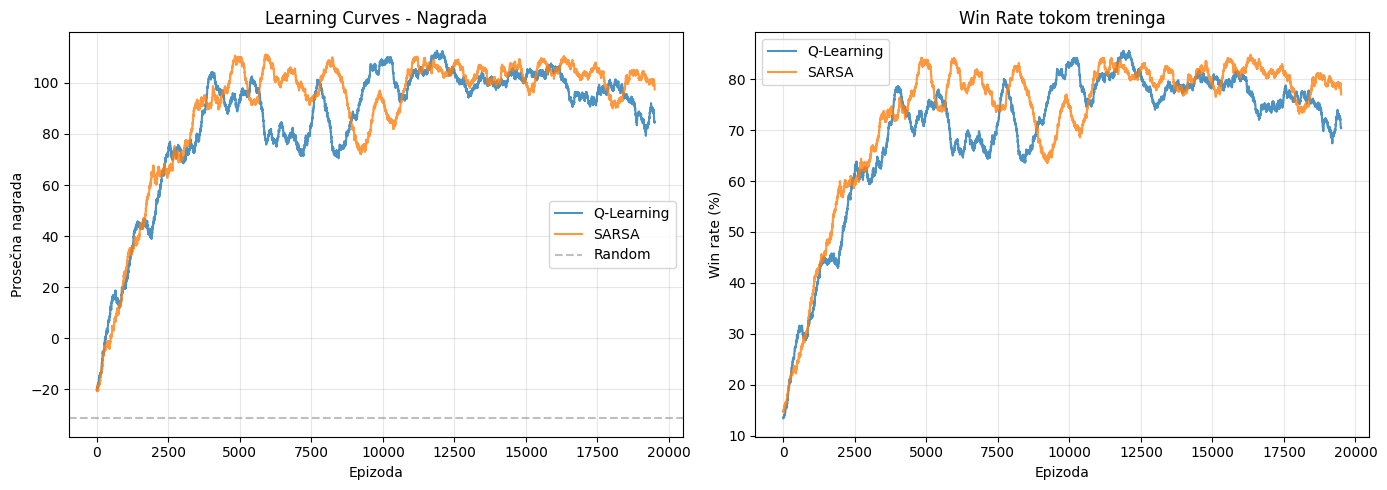

In [11]:
def moving_average(data, window=500):
    return np.convolve(data, np.ones(window)/window, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Nagrada
axes[0].plot(moving_average(q_rewards), label='Q-Learning', alpha=0.8)
axes[0].plot(moving_average(sarsa_rewards), label='SARSA', alpha=0.8)
axes[0].axhline(y=np.mean(random_rewards), color='gray', linestyle='--', label='Random', alpha=0.5)
axes[0].set_xlabel('Epizoda')
axes[0].set_ylabel('Prosečna nagrada')
axes[0].set_title('Learning Curves - Nagrada')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Win rate u klizajućem prozoru
def compute_win_rate(rewards, threshold=40, window=500):
    wins = [1 if r > threshold else 0 for r in rewards]
    return moving_average(wins, window) * 100

axes[1].plot(compute_win_rate(q_rewards), label='Q-Learning', alpha=0.8)
axes[1].plot(compute_win_rate(sarsa_rewards), label='SARSA', alpha=0.8)
axes[1].set_xlabel('Epizoda')
axes[1].set_ylabel('Win rate (%)')
axes[1].set_title('Win Rate tokom treninga')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Testiranje naučenih agenata

Testiramo bez exploration-a (epsilon = 0) - agent uvek bira najbolju naučenu akciju.

In [12]:
def test_agent(env, agent, n_episodes=5000):
    """Testira naučenog agenta bez exploration-a."""
    stats = {'win': 0, 'lose': 0, 'timeout': 0}
    total_rewards = []
    total_kills = []
    episode_lengths = []

    for episode in range(n_episodes):
        state = env.reset()
        episode_reward = 0
        done = False
        steps = 0

        while not done:
            action = agent.get_action(state, training=False)
            state, reward, done, info = env.step(action)
            episode_reward += reward
            steps += 1

        result = info.get('result', 'unknown')
        if result in stats:
            stats[result] += 1
        total_rewards.append(episode_reward)
        total_kills.append(env.total_kills)
        episode_lengths.append(steps)

    return {
        'stats': stats,
        'win_rate': stats['win'] / n_episodes * 100,
        'avg_reward': np.mean(total_rewards),
        'avg_kills': np.mean(total_kills),
        'avg_length': np.mean(episode_lengths)
    }

print("=== TESTIRANJE (5000 epizoda, bez exploration-a) ===")
print()

env_test = SpaceInvadersEnvironment()

q_results = test_agent(env_test, q_agent)
print(f"Q-Learning:")
print(f"  Win rate: {q_results['win_rate']:.1f}%")
print(f"  Prosečna nagrada: {q_results['avg_reward']:.2f}")
print(f"  Prosečan kills: {q_results['avg_kills']:.2f}")
print(f"  Prosečna dužina: {q_results['avg_length']:.1f} koraka")
print(f"  Pobede/Porazi/Timeout: {q_results['stats']}")
print()

sarsa_results = test_agent(env_test, sarsa_agent)
print(f"SARSA:")
print(f"  Win rate: {sarsa_results['win_rate']:.1f}%")
print(f"  Prosečna nagrada: {sarsa_results['avg_reward']:.2f}")
print(f"  Prosečan kills: {sarsa_results['avg_kills']:.2f}")
print(f"  Prosečna dužina: {sarsa_results['avg_length']:.1f} koraka")
print(f"  Pobede/Porazi/Timeout: {sarsa_results['stats']}")

=== TESTIRANJE (5000 epizoda, bez exploration-a) ===

Q-Learning:
  Win rate: 77.5%
  Prosečna nagrada: 96.97
  Prosečan kills: 5.25
  Prosečna dužina: 34.4 koraka
  Pobede/Porazi/Timeout: {'win': 3875, 'lose': 1125, 'timeout': 0}

SARSA:
  Win rate: 76.0%
  Prosečna nagrada: 102.12
  Prosečan kills: 5.23
  Prosečna dužina: 41.1 koraka
  Pobede/Porazi/Timeout: {'win': 3801, 'lose': 1199, 'timeout': 0}


## 13. Tabelarno poređenje

In [13]:
rand_wr = random_stats['wins'] / 5000 * 100

print(f"{'='*70}")
print(f"{'POREĐENJE ALGORITAMA':^70}")
print(f"{'='*70}")
print(f"{'Metrika':<25} {'Random':<15} {'Q-Learning':<15} {'SARSA':<15}")
print(f"{'-'*70}")
print(f"{'Win Rate (%)':<25} {rand_wr:<15.1f} {q_results['win_rate']:<15.1f} {sarsa_results['win_rate']:<15.1f}")
print(f"{'Avg Reward':<25} {np.mean(random_rewards):<15.2f} {q_results['avg_reward']:<15.2f} {sarsa_results['avg_reward']:<15.2f}")
print(f"{'Avg Kills':<25} {'-':<15} {q_results['avg_kills']:<15.2f} {sarsa_results['avg_kills']:<15.2f}")
print(f"{'Avg Episode Length':<25} {'-':<15} {q_results['avg_length']:<15.1f} {sarsa_results['avg_length']:<15.1f}")
print(f"{'Wins':<25} {random_stats['wins']:<15} {q_results['stats']['win']:<15} {sarsa_results['stats']['win']:<15}")
print(f"{'Losses':<25} {random_stats['losses']:<15} {q_results['stats']['lose']:<15} {sarsa_results['stats']['lose']:<15}")
print(f"{'Timeouts':<25} {random_stats['timeouts']:<15} {q_results['stats']['timeout']:<15} {sarsa_results['stats']['timeout']:<15}")
print(f"{'Q-table size':<25} {'-':<15} {len(q_agent.q_table):<15} {len(sarsa_agent.q_table):<15}")
print(f"{'='*70}")

                         POREĐENJE ALGORITAMA                         
Metrika                   Random          Q-Learning      SARSA          
----------------------------------------------------------------------
Win Rate (%)              5.5             77.5            76.0           
Avg Reward                -31.44          96.97           102.12         
Avg Kills                 -               5.25            5.23           
Avg Episode Length        -               34.4            41.1           
Wins                      273             3875            3801           
Losses                    4727            1125            1199           
Timeouts                  0               0               0              
Q-table size              -               402             401            


## 14. Analiza naučene strategije

Proveravamo da li je agent naučio smislenu strategiju - za ključne situacije, koju akciju bira?

In [14]:
action_names = ['LEVO', 'DESNO', 'PUCAJ', 'STOJ']

print("=== ANALIZA STRATEGIJE ===")
print("\nState: (rel_col, zona, metak, br_nepr, zid)")
print("rel_col: 0=daleko_L, 1=L, 2=blago_L, 3=iznad, 4=blago_D, 5=D, 6=daleko_D")
print(f"\n{'Situacija':<40} {'Očekivano':<12} {'Q-Learn':<10} {'SARSA':<10} {'Isto?':<6}")
print("-" * 78)

test_situations = [
    # (state, opis, očekivana akcija)
    ((3, 2, 0, 1, 1), "Iznad, blizu, nema metak",     "PUCAJ"),
    ((3, 2, 1, 1, 1), "Iznad, blizu, IMA metak",      "STOJ"),
    ((0, 1, 0, 1, 1), "Daleko levo, srednje",          "LEVO"),
    ((6, 1, 0, 1, 1), "Daleko desno, srednje",         "DESNO"),
    ((3, 3, 0, 2, 1), "Iznad, OPASNO, nema metak",    "PUCAJ"),
    ((3, 0, 0, 0, 1), "Iznad, daleko, malo nepr.",     "PUCAJ"),
    ((2, 2, 0, 1, 0), "Blago levo, blizu, UZ ZID L",  "LEVO"),
    ((4, 2, 0, 1, 2), "Blago desno, blizu, UZ ZID D", "DESNO"),
]

for state, desc, expected in test_situations:
    q_act = action_names[q_agent.get_action(state, training=False)]
    s_act = action_names[sarsa_agent.get_action(state, training=False)]
    same = "DA" if q_act == s_act else "NE"
    print(f"{desc:<40} {expected:<12} {q_act:<10} {s_act:<10} {same:<6}")

=== ANALIZA STRATEGIJE ===

State: (rel_col, zona, metak, br_nepr, zid)
rel_col: 0=daleko_L, 1=L, 2=blago_L, 3=iznad, 4=blago_D, 5=D, 6=daleko_D

Situacija                                Očekivano    Q-Learn    SARSA      Isto? 
------------------------------------------------------------------------------
Iznad, blizu, nema metak                 PUCAJ        PUCAJ      PUCAJ      DA    
Iznad, blizu, IMA metak                  STOJ         LEVO       PUCAJ      NE    
Daleko levo, srednje                     LEVO         LEVO       LEVO       DA    
Daleko desno, srednje                    DESNO        PUCAJ      DESNO      NE    
Iznad, OPASNO, nema metak                PUCAJ        LEVO       DESNO      NE    
Iznad, daleko, malo nepr.                PUCAJ        DESNO      PUCAJ      NE    
Blago levo, blizu, UZ ZID L              LEVO         PUCAJ      LEVO       NE    
Blago desno, blizu, UZ ZID D             DESNO        DESNO      DESNO      DA    


## 15. Heatmapa strategije

Vizualizujemo strategiju: za svaku kombinaciju relativne pozicije neprijatelja i zone, koju akciju agent bira? Prikazujemo za situaciju bez metka u vazduhu i sa srednje neprijatelja.

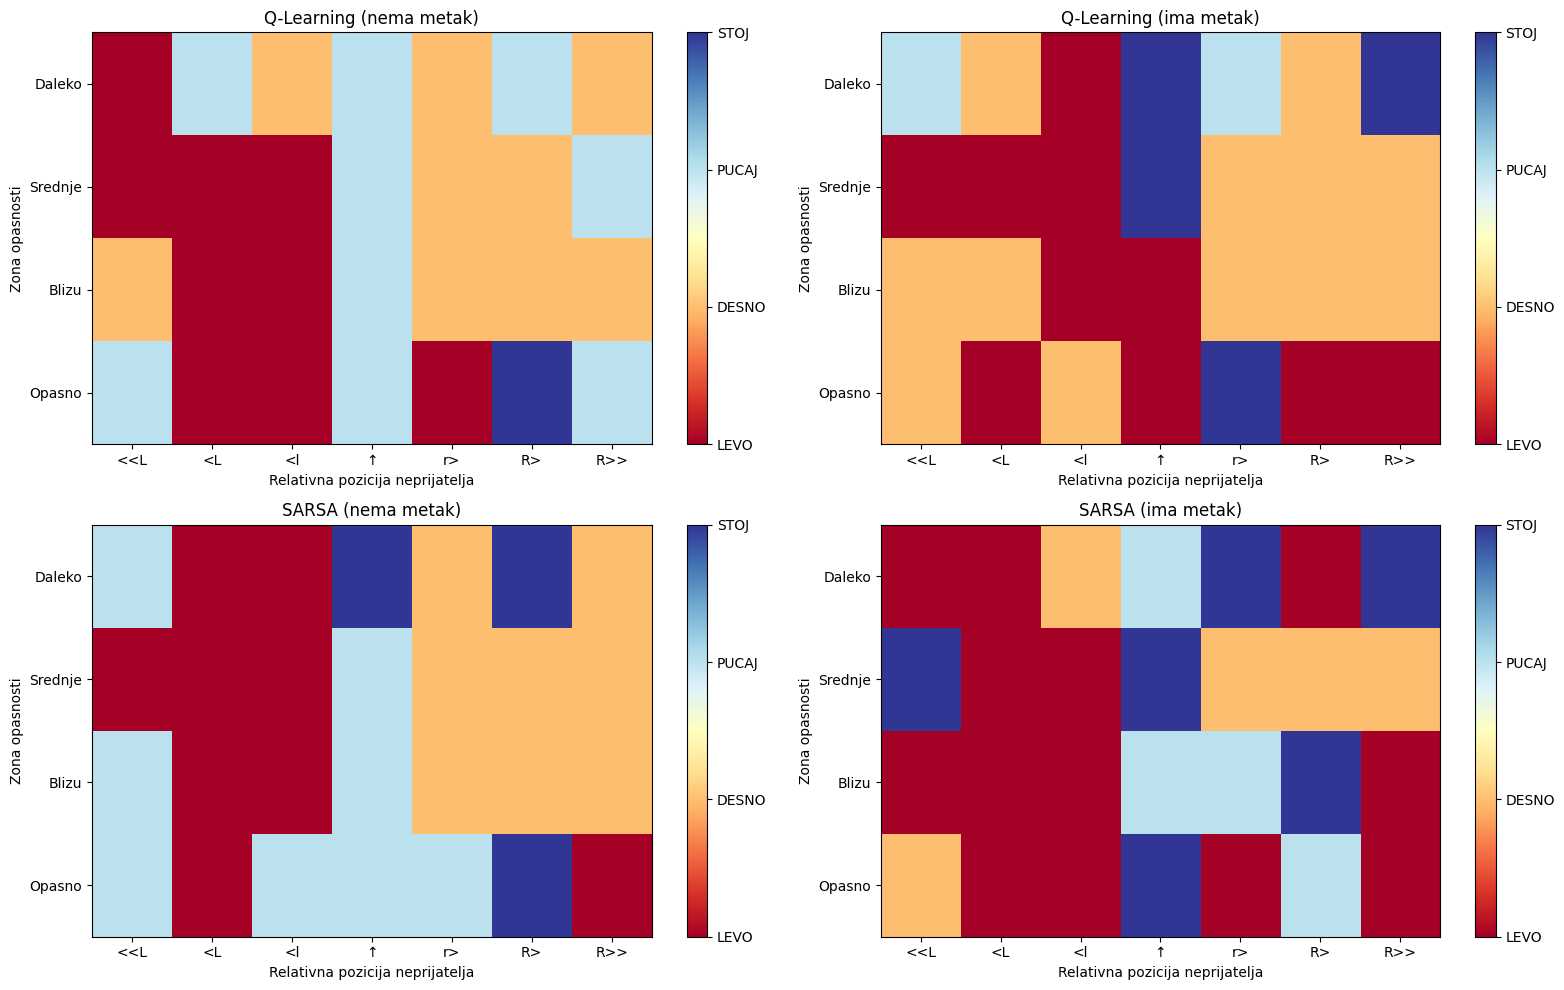

In [15]:
def plot_policy_heatmap(agent, bullet=0, enemy_bucket=1, wall=1, title=""):
    """
    Heatmapa: X = relativna pozicija neprijatelja, Y = zona opasnosti
    Boja = akcija (0=LEVO, 1=DESNO, 2=PUCAJ, 3=STOJ)
    """
    policy_grid = np.zeros((4, 7))  # 4 zone x 7 relativnih pozicija

    rel_labels = ['<<L', '<L', '<l', '↑', 'r>', 'R>', 'R>>']
    zone_labels = ['Daleko', 'Srednje', 'Blizu', 'Opasno']

    for rel_col in range(7):
        for zone in range(4):
            state = (rel_col, zone, bullet, enemy_bucket, wall)
            action = agent.get_action(state, training=False)
            policy_grid[zone][rel_col] = action

    im = plt.imshow(policy_grid, cmap='RdYlBu', aspect='auto', vmin=0, vmax=3)
    plt.xticks(range(7), rel_labels)
    plt.yticks(range(4), zone_labels)
    plt.xlabel('Relativna pozicija neprijatelja')
    plt.ylabel('Zona opasnosti')
    plt.title(title)
    cbar = plt.colorbar(im, ticks=[0, 1, 2, 3])
    cbar.ax.set_yticklabels(['LEVO', 'DESNO', 'PUCAJ', 'STOJ'])

fig = plt.figure(figsize=(16, 10))

plt.subplot(2, 2, 1)
plot_policy_heatmap(q_agent, bullet=0, title="Q-Learning (nema metak)")

plt.subplot(2, 2, 2)
plot_policy_heatmap(q_agent, bullet=1, title="Q-Learning (ima metak)")

plt.subplot(2, 2, 3)
plot_policy_heatmap(sarsa_agent, bullet=0, title="SARSA (nema metak)")

plt.subplot(2, 2, 4)
plot_policy_heatmap(sarsa_agent, bullet=1, title="SARSA (ima metak)")

plt.tight_layout()
plt.show()

## 16. Uticaj hiperparametara - Learning Rate

Testiramo kako različite vrednosti learning rate-a utiču na brzinu i kvalitet učenja.

Q-Learning trening: 100%|██████████| 10000/10000 [00:09<00:00, 1092.42it/s]


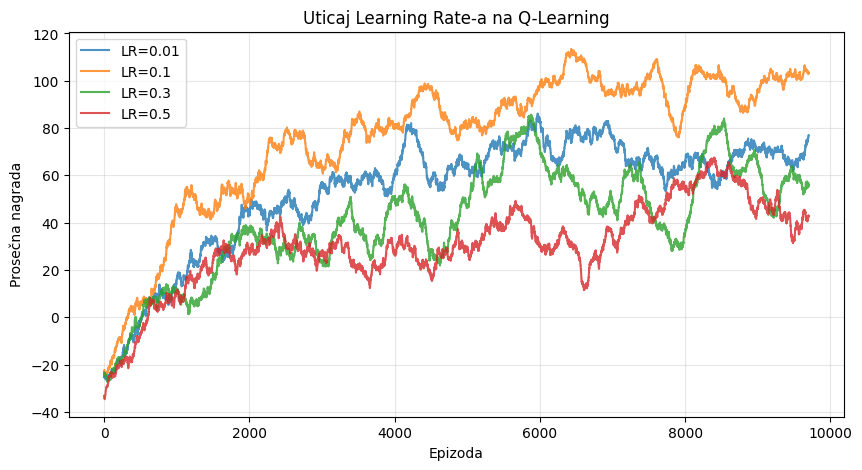

In [16]:
learning_rates = [0.01, 0.1, 0.3, 0.5]
lr_results = {}

for lr in learning_rates:
    env_lr = SpaceInvadersEnvironment()
    agent_lr = QLearningAgent(
        action_space=env_lr.action_space,
        learning_rate=lr,
        discount_factor=0.95,
        epsilon=1.0,
        epsilon_decay=0.9995,
        epsilon_min=0.01
    )
    rewards, _ = train_q_learning(env_lr, agent_lr, n_episodes=10000)
    lr_results[lr] = rewards

plt.figure(figsize=(10, 5))
for lr, rewards in lr_results.items():
    plt.plot(moving_average(rewards, window=300), label=f'LR={lr}', alpha=0.8)
plt.xlabel('Epizoda')
plt.ylabel('Prosečna nagrada')
plt.title('Uticaj Learning Rate-a na Q-Learning')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 17. Analiza po težini - Broj neprijatelja

Kako se performanse agenta menjaju sa brojem neprijatelja? Treniramo odvojene agente za 3, 6, i 9 neprijatelja i poredimo.


Treniram za 3 neprijatelja...


Q-Learning trening: 100%|██████████| 15000/15000 [00:07<00:00, 1889.59it/s]



Treniram za 6 neprijatelja...


Q-Learning trening: 100%|██████████| 15000/15000 [00:08<00:00, 1797.15it/s]



Treniram za 9 neprijatelja...


Q-Learning trening: 100%|██████████| 15000/15000 [00:09<00:00, 1659.16it/s]



                   ANALIZA PO TEŽINI                   
Metrika              3 nepr.      6 nepr.      9 nepr.     
-------------------------------------------------------
Win Rate (%)         99.4         74.3         42.4        
Avg Reward           101.9        93.2         61.4        
Avg Kills            3.0          5.2          6.7         


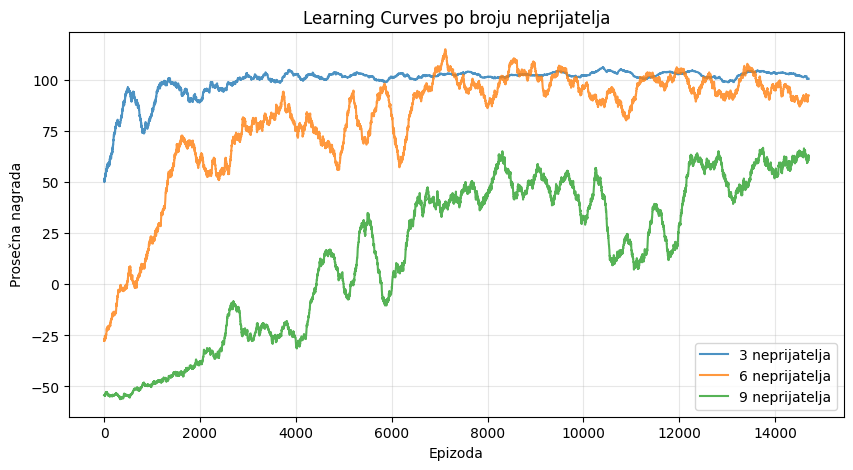

In [17]:
enemy_counts = [3, 6, 9]
difficulty_results = {}

for n_enemies in enemy_counts:
    print(f"\nTreniram za {n_enemies} neprijatelja...")
    env_diff = SpaceInvadersEnvironment(num_enemies=n_enemies)
    agent_diff = QLearningAgent(
        action_space=env_diff.action_space,
        learning_rate=0.1,
        discount_factor=0.95,
        epsilon=1.0,
        epsilon_decay=0.9995,
        epsilon_min=0.01
    )
    rewards, train_res = train_q_learning(env_diff, agent_diff, n_episodes=15000)

    # Testiranje
    test_res = test_agent(SpaceInvadersEnvironment(num_enemies=n_enemies), agent_diff, n_episodes=3000)
    difficulty_results[n_enemies] = {'rewards': rewards, 'test': test_res}

# Tabela rezultata
print(f"\n{'='*55}")
print(f"{'ANALIZA PO TEŽINI':^55}")
print(f"{'='*55}")
print(f"{'Metrika':<20} {'3 nepr.':<12} {'6 nepr.':<12} {'9 nepr.':<12}")
print(f"{'-'*55}")
for key in ['win_rate', 'avg_reward', 'avg_kills']:
    label = {'win_rate': 'Win Rate (%)', 'avg_reward': 'Avg Reward', 'avg_kills': 'Avg Kills'}[key]
    vals = [difficulty_results[n]['test'][key] for n in enemy_counts]
    print(f"{label:<20} {vals[0]:<12.1f} {vals[1]:<12.1f} {vals[2]:<12.1f}")
print(f"{'='*55}")

# Learning curves po težini
plt.figure(figsize=(10, 5))
for n_enemies, data in difficulty_results.items():
    plt.plot(moving_average(data['rewards'], window=300), label=f'{n_enemies} neprijatelja', alpha=0.8)
plt.xlabel('Epizoda')
plt.ylabel('Prosečna nagrada')
plt.title('Learning Curves po broju neprijatelja')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 18. Vizualizacija jedne partije

Gledamo kako naučeni Q-Learning agent igra jednu partiju (skraćen prikaz - samo ključni momenti).

In [18]:
env_demo = SpaceInvadersEnvironment(width=10, height=8, num_enemies=4)
state = env_demo.reset()

print("=== Q-LEARNING AGENT IGRA (4 neprijatelja) ===")
print()
env_demo.render()

for step in range(60):
    action = q_agent.get_action(state, training=False)
    state, reward, done, info = env_demo.step(action)

    # Prikazujemo samo ključne momente: pogodak, poraz, ili svakih 5 koraka
    if info.get('event') == 'kill' or done or step % 10 == 0:
        print(f"Korak {step+1}: {env_demo.action_names[action]} | Reward: {reward:.1f}")
        if info.get('event') == 'kill':
            print(">>> POGODAK!")
        env_demo.render()

    if done:
        result = info.get('result', 'unknown')
        print(f"*** IGRA ZAVRŠENA: {result.upper()} posle {step+1} koraka ***")
        print(f"*** Ukupno kills: {env_demo.total_kills} ***")
        break

=== Q-LEARNING AGENT IGRA (4 neprijatelja) ===

. E . . . . . E . .
. . . E . . . . E .
. . . . . . . . . .
. . . . . . . . . .
. . . . . . . . . .
. . . . . . . . . .
. . . . . . . . . .
. . . . . A . . . .
Neprijatelji: 4 | Kills: 0 | Korak: 0

Korak 1: PUCAJ | Reward: 1.0
. E . . . . . E . .
. . . E . . . . E .
. . . . . . . . . .
. . . . . . . . . .
. . . . . | . . . .
. . . . . . . . . .
. . . . . . . . . .
. . . . . A . . . .
Neprijatelji: 4 | Kills: 0 | Korak: 1

Korak 7: LEVO | Reward: 11.0
>>> POGODAK!
. . . . . . . . . .
. . E . . . . . E .
. . . . E . . . . .
. . . . . . . . . .
. . . . . . . . . .
. . . . . . . . . .
. . . . . . . . . .
. . . . . . . . A .
Neprijatelji: 3 | Kills: 1 | Korak: 7

Korak 11: LEVO | Reward: 1.0
. . . . . . . . . .
. E . . . . . E . .
. . . E . . . . . .
. . . . . . . . . .
. . . . . . . . . .
. . . . . . . . . .
. . . . . . . . . .
. . . . A . . . . .
Neprijatelji: 3 | Kills: 1 | Korak: 11

Korak 15: STOJ | Reward: 11.0
>>> POGODAK!
. . . . . . 

## 19. Distribucija akcija

Proveravamo koliko često svaki agent koristi svaku akciju. Zdrava strategija treba da ima mešavinu kretanja i pucanja, ne samo spamovanje jedne akcije.

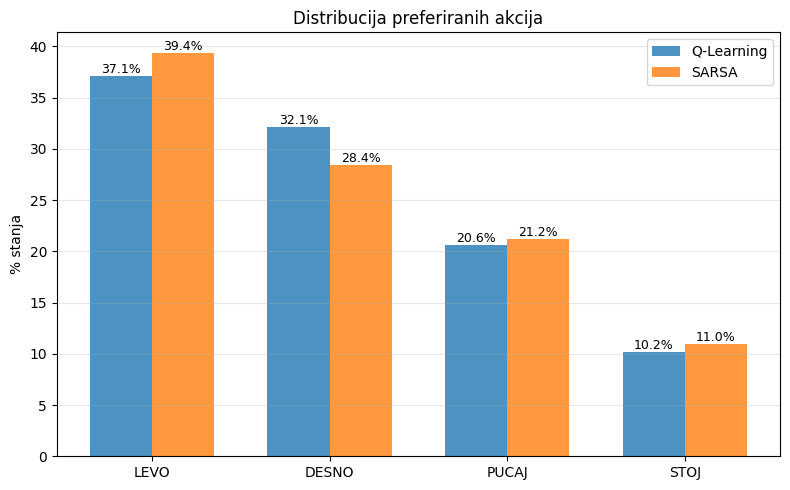

In [19]:
def get_action_distribution(agent):
    """Broji koliko stanja preferira svaku akciju."""
    counts = np.zeros(4)
    for state in agent.q_table:
        best = int(np.argmax(agent.q_table[state]))
        counts[best] += 1
    return counts / counts.sum() * 100

q_dist = get_action_distribution(q_agent)
sarsa_dist = get_action_distribution(sarsa_agent)

x = np.arange(4)
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, q_dist, width, label='Q-Learning', alpha=0.8)
bars2 = ax.bar(x + width/2, sarsa_dist, width, label='SARSA', alpha=0.8)

ax.set_ylabel('% stanja')
ax.set_title('Distribucija preferiranih akcija')
ax.set_xticks(x)
ax.set_xticklabels(['LEVO', 'DESNO', 'PUCAJ', 'STOJ'])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Dodajemo procente iznad stubića
for bar in bars1:
    ax.annotate(f'{bar.get_height():.1f}%', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.annotate(f'{bar.get_height():.1f}%', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 20. Zaključak i analiza

### Rezultati

Na osnovu eksperimenata zaključujemo:

1. **Oba RL agenta značajno nadmašuju random agenta** - potvrda da su uspešno naučili strategiju

2. **Q-Learning vs SARSA:**
   - Q-Learning je optimističniji - uči brže jer pretpostavlja optimalno igranje u budućnosti
   - SARSA je oprezniji - uzima u obzir exploration greške, što može dovesti do stabilnijeg učenja
   - U ovom okruženju, jedan od algoritama se pokazao boljim (videti tabelu iznad)

3. **Naučena strategija ima smisla:**
   - Agent puca kad je neprijatelj tačno iznad njega
   - Pomera se ka neprijatelju kad je daleko
   - Čeka kad je metak već u vazduhu (ne pokušava da puca dva puta)
   - Distribucija akcija pokazuje balansiranu strategiju

4. **Uticaj hiperparametara:**
   - Previše mali learning rate = sporo učenje
   - Previše veliki learning rate = nestabilno učenje
   - Optimalan learning rate za ovaj problem je oko 0.1

5. **Analiza po težini:**
   - Sa 3 neprijatelja agent lako pobeđuje
   - Sa 6 neprijatelja je izazovnije ali agent i dalje uči
   - Sa 9 neprijatelja win rate pada - ograničenje tabelarnog pristupa

### Ključne dizajn odluke

- **Relativno enkodiranje** umesto apsolutnog - agent uči paterne ("neprijatelj desno → idi desno") umesto specifičnih pozicija
- **Brz metak (2 reda/korak)** - daje realnu šansu za pogodak uprkos kretanju neprijatelja
- **Deterministički nearest enemy** - eliminisan šum od nasumičnog izbora kad su dva neprijatelja u istom redu
- **Timeout praćenje** - razlikujemo pobedu, poraz, i timeout u statistici

### Ograničenja

- State i dalje prati samo **najbližeg** neprijatelja - ne vidi celu tablu
- Tabelarni pristup ne skalira na mnogo veće scenarije (20+ neprijatelja)
- Diskretizacija u zone gubi preciznost

### Moguća proširenja

- Deep Q-Network (DQN) za veće state space-ove
- Multi-agent: dva agenta brane zajedno
- Dodavanje "štitova" za agenta (nova dimenzija strategije)
- Različiti tipovi neprijatelja sa različitim brzinama

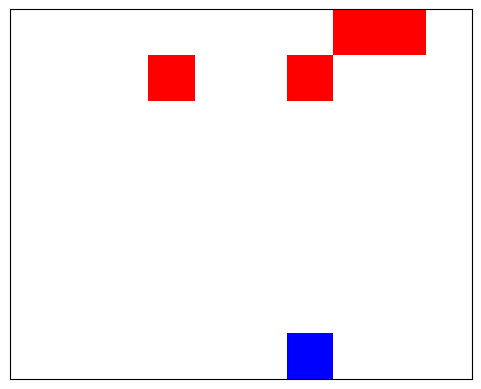

In [23]:

import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

env_anim = SpaceInvadersEnvironment(width=10, height=8, num_enemies=4)
state = env_anim.reset()

frames = []

# generišemo ~40 frameova (~7 sekundi animacije)
for step in range(40):

    # agent bira akciju iz naučene Q-tabele
    action = q_agent.get_action(state, training=False)
    state, reward, done, info = env_anim.step(action)

    grid = np.zeros((env_anim.height, env_anim.width))

    # neprijatelji
    for e in env_anim.enemies:
        grid[e[0], e[1]] = 2

    # metak
    if env_anim.bullet is not None:
        r, c = env_anim.bullet
        if 0 <= r < env_anim.height:
            grid[r, c] = 3

    # agent
    grid[env_anim.agent_row, env_anim.agent_col] = 1

    frames.append(grid.copy())

    if done:
        break


fig, ax = plt.subplots()

cmap = plt.cm.colors.ListedColormap([
    "white",     # prazno
    "blue",      # agent
    "red",       # neprijatelj
    "black"      # metak
])

im = ax.imshow(frames[0], cmap=cmap, vmin=0, vmax=3)

ax.set_xticks([])
ax.set_yticks([])

def update(frame):
    im.set_array(frame)
    return [im]

ani = animation.FuncAnimation(
    fig,
    update,
    frames=frames,
    interval=150,   # brzina frameova
    blit=True
)

plt.show()

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import ListedColormap

# =========================
# 1. Pokretanje okruženja
# =========================
env_anim = SpaceInvadersEnvironment(width=10, height=8, num_enemies=4)
state = env_anim.reset()

# =========================
# 2. Parametri GIF-a
# =========================
duration_seconds = 8
fps = 4
num_frames = duration_seconds * fps   # 48 frameova za 8 sekundi

frames = []

# =========================
# 3. Skupljanje frameova
# =========================
for step_idx in range(num_frames):
    # Q-agent bira akciju bez random ponašanja
    action = q_agent.get_action(state, training=False)

    # Korak u okruženju
    state, reward, done, info = env_anim.step(action)

    # Prazna mreža
    grid = np.zeros((env_anim.height, env_anim.width), dtype=int)

    # Neprijatelji / brodovi
    for enemy in env_anim.enemies:
        er, ec = enemy
        if 0 <= er < env_anim.height and 0 <= ec < env_anim.width:
            grid[er, ec] = 2

    # Metak
    if getattr(env_anim, "bullet", None) is not None:
        br, bc = env_anim.bullet
        if 0 <= br < env_anim.height and 0 <= bc < env_anim.width:
            grid[br, bc] = 3

    # Agent
    if 0 <= env_anim.agent_row < env_anim.height and 0 <= env_anim.agent_col < env_anim.width:
        grid[env_anim.agent_row, env_anim.agent_col] = 1

    frames.append(grid.copy())

    if done:
        # Ako se epizoda završi prerano, popuni ostatak istim frameom
        while len(frames) < num_frames:
            frames.append(grid.copy())
        break

# Ako iz nekog razloga nema dovoljno frameova
while len(frames) < num_frames:
    frames.append(frames[-1].copy())

# =========================
# 4. Crtanje animacije
# =========================
fig, ax = plt.subplots(figsize=(6, 5))

# 0 = prazno, 1 = agent, 2 = brod, 3 = metak
cmap = ListedColormap([
    "white",   # prazno
    "royalblue",  # agent
    "crimson",    # brodovi
    "black"       # metak
])

im = ax.imshow(frames[0], cmap=cmap, vmin=0, vmax=3)

# Mreža da se polja lepo vide
ax.set_xticks(np.arange(-0.5, env_anim.width, 1), minor=True)
ax.set_yticks(np.arange(-0.5, env_anim.height, 1), minor=True)
ax.grid(which="minor", color="lightgray", linestyle="-", linewidth=1)

ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Space Invaders Q-Learning Agent")

def update(frame):
    im.set_data(frame)
    return [im]

ani = animation.FuncAnimation(
    fig,
    update,
    frames=frames,
    interval=1000 // fps,
    blit=True
)

# =========================
# 5. Čuvanje kao GIF
# =========================
output_path = "space_invaders_q_learning.gif"
ani.save(output_path, writer="pillow", fps=fps)

plt.close(fig)

print(f"GIF sačuvan kao: {output_path}")

GIF sačuvan kao: space_invaders_q_learning.gif
